In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [3]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [4]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)

(60000, 28, 28, 1)


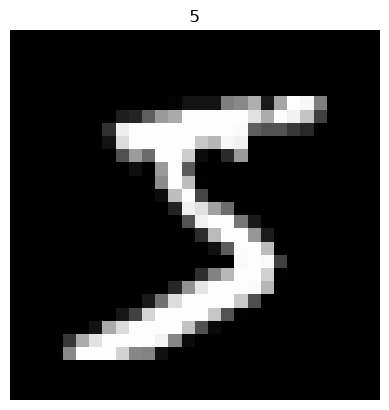

In [5]:
plt.imshow(X_train[0].squeeze(), cmap="gray")
plt.title(y_train[0])
plt.axis("off")
plt.show()

In [6]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        10,
        activation="softmax"
    )

])

c:\Users\ADMIN\OneDrive\Desktop\AI PROJECTS\Handwritten_Digit_Recognizer\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10
)

datagen.fit(X_train)

In [10]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 61ms/step - accuracy: 0.8833 - loss: 0.3703 - val_accuracy: 0.9861 - val_loss: 0.0434
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9587 - loss: 0.1352 - val_accuracy: 0.9901 - val_loss: 0.0314
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.9707 - loss: 0.0966 - val_accuracy: 0.9895 - val_loss: 0.0295
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.9755 - loss: 0.0806 - val_accuracy: 0.9915 - val_loss: 0.0253
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 73s 77ms/step - accuracy: 0.9780 - loss: 0.0717 - val_accuracy: 0.9918 - val_loss: 0.0224
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.9812 - loss: 0.0609 - val_accuracy: 0.9935 - val_loss: 0.0188
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 57ms/step - accuracy: 0.9817 - loss: 0.0603 - val_accuracy: 0.9937 - val_loss: 0.0198
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 57s 61ms/step - accuracy: 0.9838 - loss: 0.0554 - 

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9932 - loss: 0.0204
Test Accuracy: 0.9932000041007996


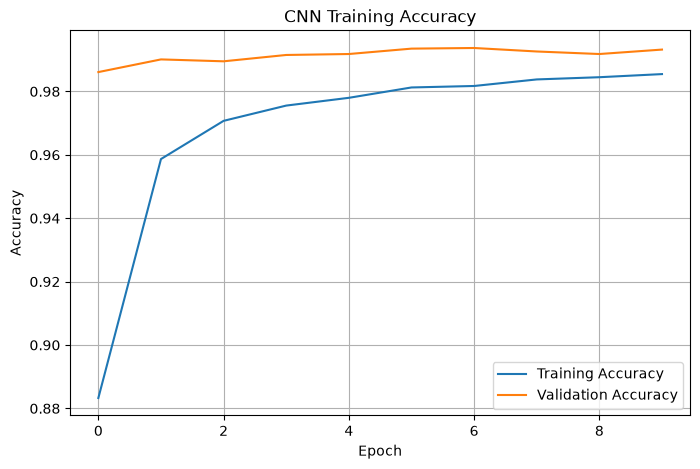

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training Accuracy")
plt.legend()

plt.grid(True)

plt.show()

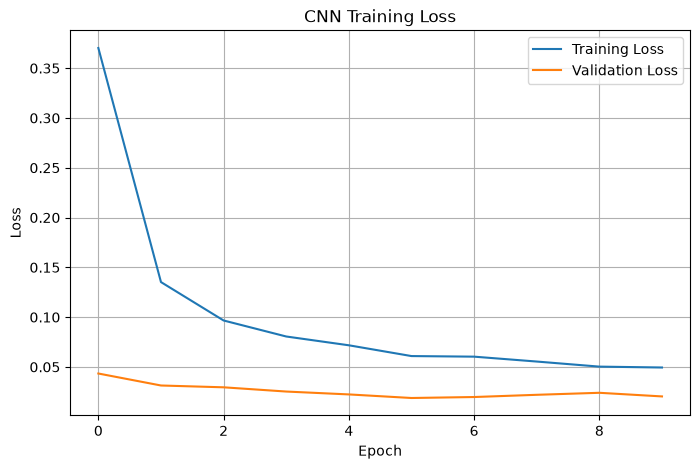

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.legend()

plt.grid(True)

plt.show()

In [14]:
model.save("model/digit_model.keras")

Predicted: 7
Actual: 7


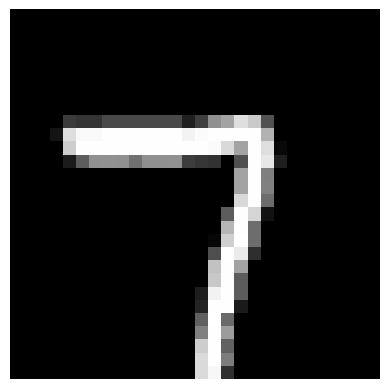

In [15]:
import numpy as np

index = np.random.randint(0, 10000)

prediction = model.predict(X_test[index:index+1], verbose=0)

predicted_digit = np.argmax(prediction)

print("Predicted:", predicted_digit)
print("Actual:", y_test[index])

plt.imshow(X_test[index].squeeze(), cmap="gray")
plt.axis("off")
plt.show()

In [16]:
prediction = model.predict(X_test[index:index+1], verbose=0)[0]

top3 = np.argsort(prediction)[-3:][::-1]

print("Top 3 Predictions:")

for digit in top3:
    print(f"Digit {digit}: {prediction[digit]*100:.2f}%")

Top 3 Predictions:
Digit 7: 100.00%
Digit 9: 0.00%
Digit 2: 0.00%
